<a href="https://www.kaggle.com/code/simarbirsinghsandhu/complete-eda-on-comp-and-original-dataset?scriptVersionId=319084751" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏎️ F1 Pit Stops | Deep EDA — What the Data Actually Says
### Playground Series S6E5

This notebook finds the exact signals in the data that drive that decision for the pitstop.

**5 non-obvious findings inside:**
- HARD tyres have the *highest* pit rate — and it's completely misleading
- `LapTime_Delta` has near-zero correlation with pitting, yet it's a real signal
- `Cumulative_Degradation` is **corrupted** in the synthetic data (2025 rows)
- The removed `Normalized_TyreLife` column can be reconstructed
- All 9 features are shifted vs original — but 3 of them barely at all

---
*Upvote if useful 🙌 | [RealMLP](https://www.kaggle.com/code/simarbirsinghsandhu/realmlp-encoding-fe) (PB 0.95253) | [CatBoost](https://www.kaggle.com/code/simarbirsinghsandhu/catboost-gpu-fe-encoding) (PB: 0.95) | [XGB GPU](https://www.kaggle.com/code/simarbirsinghsandhu/xgboost-gpu-fe-encoding)*

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

In [2]:
BG       = '#0f0f0f'
PANEL    = '#1a1a1a'
RED      = '#e10600'
YELLOW   = '#ffd700'
CYAN     = '#00d2ff'
WHITE    = '#f0f0f0'
GRAY     = '#555555'

COMPOUND_COLORS = {
    'SOFT':         '#e10600',
    'MEDIUM':       '#ffd700',
    'HARD':         '#f0f0f0',
    'INTERMEDIATE': '#39b54a',
    'WET':          '#0067ff',
}

def set_f1_style():
    plt.rcParams.update({
        'figure.facecolor':  BG,
        'axes.facecolor':    PANEL,
        'axes.edgecolor':    '#333333',
        'axes.labelcolor':   WHITE,
        'axes.titlecolor':   WHITE,
        'xtick.color':       WHITE,
        'ytick.color':       WHITE,
        'text.color':        WHITE,
        'grid.color':        '#2a2a2a',
        'grid.alpha':        1.0,
        'legend.facecolor':  '#1a1a1a',
        'legend.edgecolor':  '#333333',
        'font.family':       'monospace',
    })

set_f1_style()

## Load Data

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
orig  = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')

orig.drop(columns=['Normalized_TyreLife'], inplace=True)

print("=" * 55)
print("  🏎️  F1 PIT STOP PREDICTION — S6E5")
print("=" * 55)
print(f"  Train : {train.shape[0]:>7,} rows × {train.shape[1]} cols")
print(f"  Test  : {test.shape[0]:>7,} rows × {test.shape[1]} cols")
print(f"  Orig  : {orig.shape[0]:>7,} rows × {orig.shape[1]} cols")
print(f"  Target rate  : {train['PitNextLap'].mean():.4f}  (1-in-5 laps)")
print(f"  Nulls        : {train.isnull().sum().sum()} (none — clean dataset)")
print("=" * 55)

  🏎️  F1 PIT STOP PREDICTION — S6E5
  Train : 439,140 rows × 16 cols
  Test  : 188,165 rows × 15 cols
  Orig  : 101,371 rows × 15 cols
  Target rate  : 0.1990  (1-in-5 laps)
  Nulls        : 0 (none — clean dataset)


## DATASET OVERVIEW & TARGET DISTRIBUTION

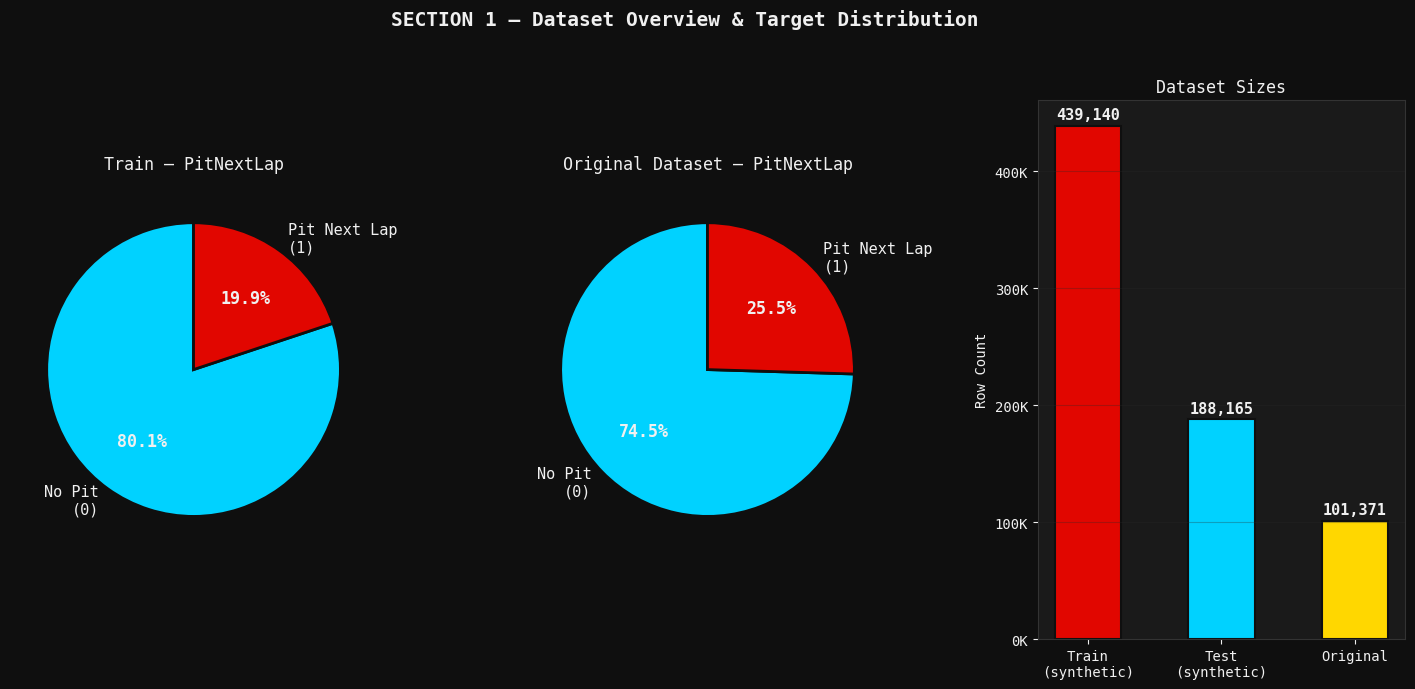

In [4]:
fig = plt.figure(figsize=(18, 7), facecolor=BG)
fig.suptitle('SECTION 1 — Dataset Overview & Target Distribution',
             fontsize=14, color=WHITE, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# 1a. Target pie — train
ax1 = fig.add_subplot(gs[0])
vals  = train['PitNextLap'].value_counts().sort_index()
wedge_colors = [CYAN, RED]
wedges, texts, autotexts = ax1.pie(
    vals, labels=['No Pit\n(0)', 'Pit Next Lap\n(1)'],
    colors=wedge_colors, autopct='%1.1f%%', startangle=90,
    textprops={'color': WHITE, 'fontsize': 11},
    wedgeprops={'edgecolor': BG, 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax1.set_title('Train — PitNextLap', color=WHITE, fontsize=12, pad=12)

# 1b. Target pie — original
ax2 = fig.add_subplot(gs[1])
vals_o = orig['PitNextLap'].value_counts().sort_index()
wedges2, texts2, autotexts2 = ax2.pie(
    vals_o, labels=['No Pit\n(0)', 'Pit Next Lap\n(1)'],
    colors=wedge_colors, autopct='%1.1f%%', startangle=90,
    textprops={'color': WHITE, 'fontsize': 11},
    wedgeprops={'edgecolor': BG, 'linewidth': 2}
)
for at in autotexts2: at.set_fontsize(12); at.set_fontweight('bold')
ax2.set_title('Original Dataset — PitNextLap', color=WHITE, fontsize=12, pad=12)

# 1c. Dataset size comparison bar
ax3 = fig.add_subplot(gs[2])
datasets  = ['Train\n(synthetic)', 'Test\n(synthetic)', 'Original']
sizes     = [len(train), len(test), len(orig)]
bar_clrs  = [RED, CYAN, YELLOW]
bars = ax3.bar(datasets, sizes, color=bar_clrs, edgecolor=BG, linewidth=1.5, width=0.5)
for bar, sz in zip(bars, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'{sz:,}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
ax3.set_title('Dataset Sizes', color=WHITE, fontsize=12)
ax3.set_ylabel('Row Count', color=WHITE)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax3.set_facecolor(PANEL)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

| | Train (Synthetic) | Original |
|---|---|---|
| Rows | 439,140 | 101,371 |
| Pit rate | **19.9%** | **25.5%** |
| Nulls | 0 | 0 |

**Key insight:** The competition host downsampled pit events by ~5.5 percentage points in the synthetic data.  
Models trained purely on synthetic data will **underestimate pit probability**.  
The original dataset should be used as extra training data — but with care (see Section 6 on dataset shift).

## TYRE COMPOUND ANALYSIS

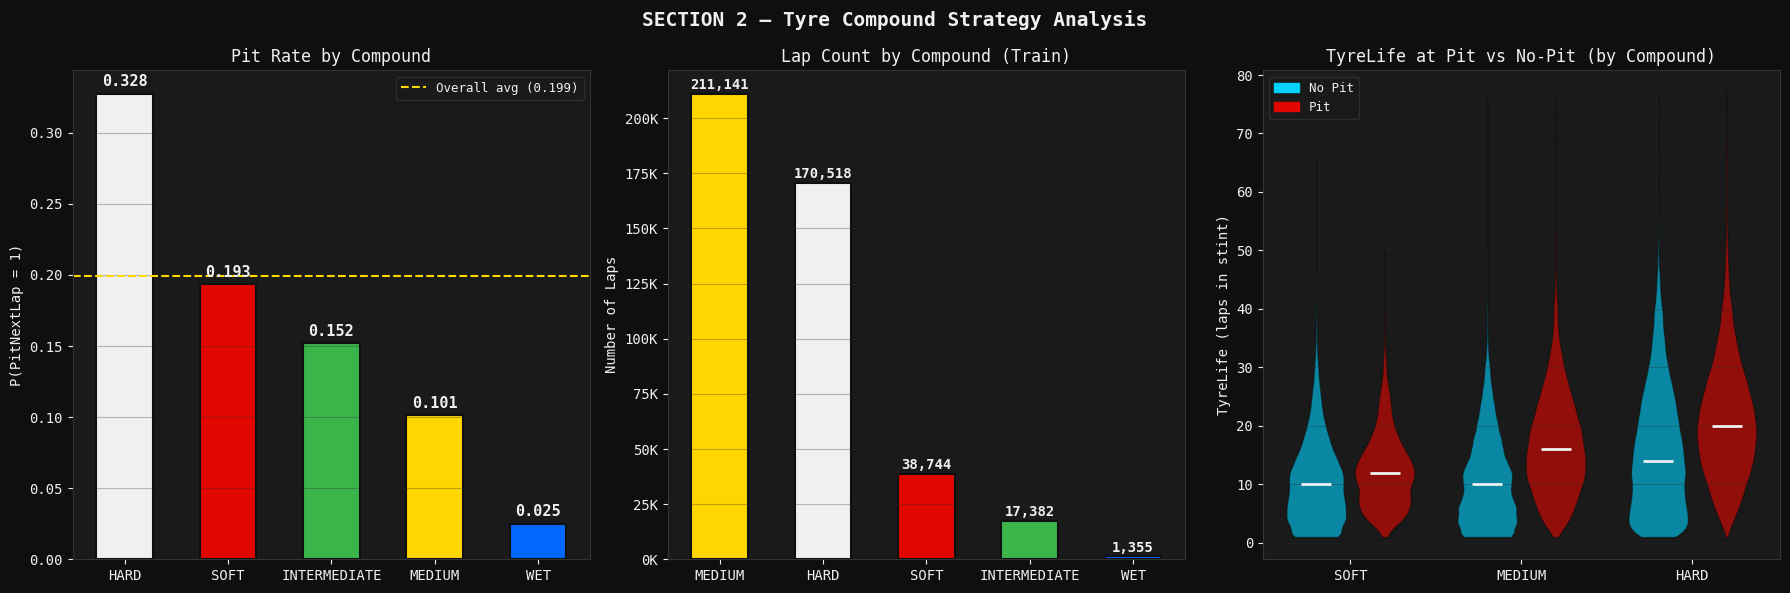

In [5]:
# Pit rate & count per compound
comp_stats = (train.groupby('Compound')['PitNextLap']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'PitRate', 'count': 'Count'})
              .sort_values('PitRate', ascending=False)
              .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)
fig.suptitle('SECTION 2 — Tyre Compound Strategy Analysis',
             fontsize=14, color=WHITE, fontweight='bold')

# 2a. Pit rate by compound
ax = axes[0]
bar_clrs = [COMPOUND_COLORS.get(c, GRAY) for c in comp_stats['Compound']]
bars = ax.bar(comp_stats['Compound'], comp_stats['PitRate'],
              color=bar_clrs, edgecolor=BG, linewidth=1.5, width=0.55)
for bar, val in zip(bars, comp_stats['PitRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
ax.set_title('Pit Rate by Compound', color=WHITE, fontsize=12)
ax.set_ylabel('P(PitNextLap = 1)', color=WHITE)
ax.set_facecolor(PANEL)
ax.grid(axis='y', alpha=0.3)
ax.axhline(train['PitNextLap'].mean(), color=YELLOW, linestyle='--',
           linewidth=1.5, label=f'Overall avg ({train["PitNextLap"].mean():.3f})')
ax.legend(fontsize=9)

# 2b. Count of laps per compound (train)
ax2 = axes[1]
count_sorted = comp_stats.sort_values('Count', ascending=False)
bar_clrs2 = [COMPOUND_COLORS.get(c, GRAY) for c in count_sorted['Compound']]
bars2 = ax2.bar(count_sorted['Compound'], count_sorted['Count'],
                color=bar_clrs2, edgecolor=BG, linewidth=1.5, width=0.55)
for bar, val in zip(bars2, count_sorted['Count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
             f'{val:,}', ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
ax2.set_title('Lap Count by Compound (Train)', color=WHITE, fontsize=12)
ax2.set_ylabel('Number of Laps', color=WHITE)
ax2.set_facecolor(PANEL)
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 2c. TyreLife distribution per compound (pit vs no-pit), violin
ax3 = axes[2]
compounds_ordered = ['SOFT', 'MEDIUM', 'HARD']
compounds_in_data = [c for c in compounds_ordered if c in train['Compound'].unique()]
positions = np.arange(len(compounds_in_data))

for i, comp in enumerate(compounds_in_data):
    sub = train[train['Compound'] == comp]
    for j, (pit_val, clr, lbl) in enumerate([(0, CYAN, 'No Pit'), (1, RED, 'Pit')]):
        data = sub[sub['PitNextLap'] == pit_val]['TyreLife'].values
        offset = -0.2 + j * 0.4
        parts = ax3.violinplot(data, positions=[i + offset],
                               widths=0.35, showmedians=True,
                               showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(clr)
            pc.set_alpha(0.6)
            pc.set_edgecolor(BG)
        parts['cmedians'].set_color(WHITE)
        parts['cmedians'].set_linewidth(2)

ax3.set_xticks(positions)
ax3.set_xticklabels(compounds_in_data)
ax3.set_title('TyreLife at Pit vs No-Pit (by Compound)', color=WHITE, fontsize=12)
ax3.set_ylabel('TyreLife (laps in stint)', color=WHITE)
ax3.set_facecolor(PANEL)
ax3.grid(axis='y', alpha=0.3)
legend_patches = [mpatches.Patch(color=CYAN, label='No Pit'),
                  mpatches.Patch(color=RED,  label='Pit')]
ax3.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig('02_compound_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Raw pit rates by compound:**

| Compound | Pit Rate | Median TyreLife at Pit |
|---|---|---|
| HARD | 32.8% 🔴 | 20 laps |
| SOFT | 19.3% | 12 laps |
| INTERMEDIATE | 15.2% | 17 laps |
| MEDIUM | 10.1% | 16 laps |
| WET | 2.5% 🔵 | 11 laps |

**⚠️ HARD having the highest pit rate is counterintuitive — here's why:**  
Hard tyres run the longest stints (median 23 laps vs Soft's 14).  
More laps on track = more opportunities to accumulate to pit age.  
The raw pit rate is a **length-biased statistic** — it counts total events, not per-lap risk.

At *equivalent* TyreLife, Soft tyres hit peak pit probability far earlier:
- **SOFT** → peak pit risk at lap **13** (26% chance)
- **MEDIUM** → peak pit risk at lap **49** (51% chance)  
- **HARD** → peak pit risk at lap **61** (93% chance — almost certain)

> This is exactly why a single `TyreLife` threshold is not enough.  
> **`TyreLife × Compound` interaction is the single most important feature in this competition.**

## TYRE LIFE: THE CORE PREDICTOR

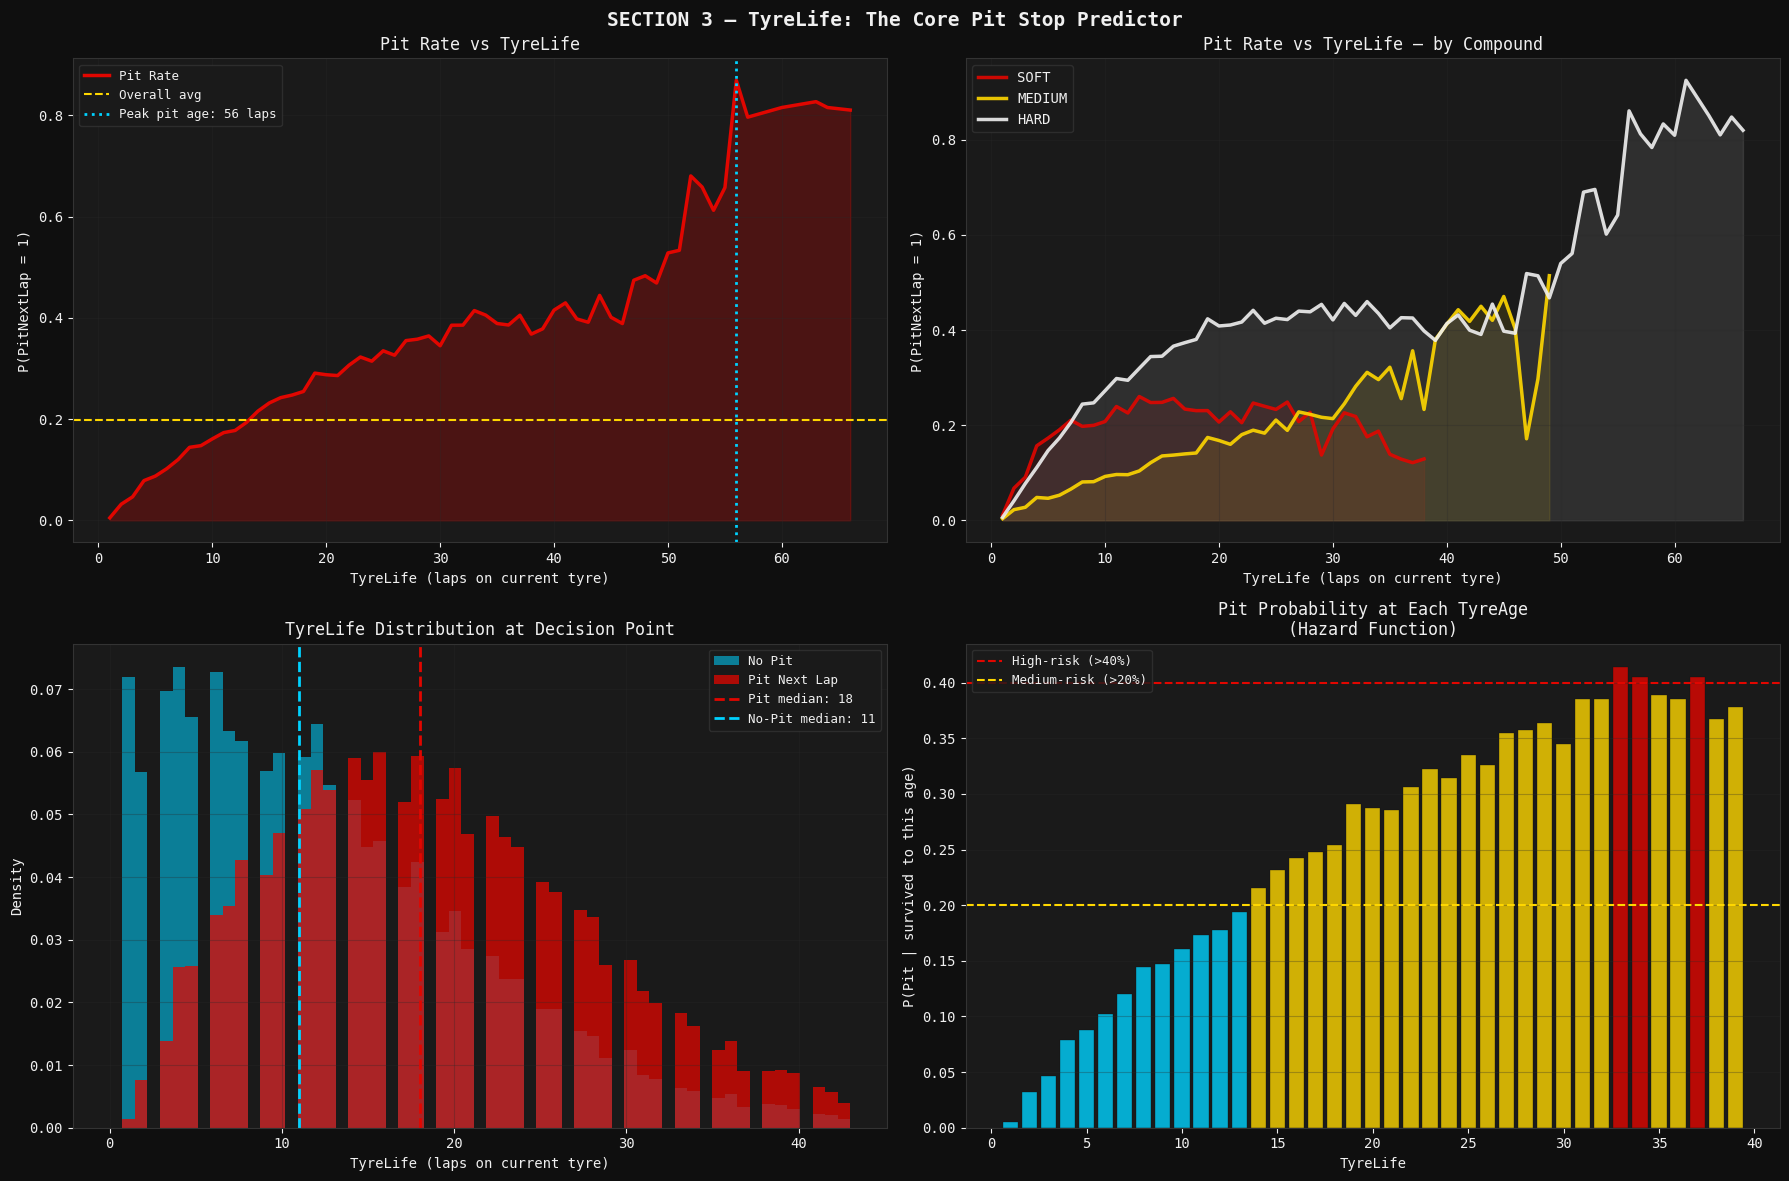

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('SECTION 3 — TyreLife: The Core Pit Stop Predictor',
             fontsize=14, color=WHITE, fontweight='bold')

# 3a. Pit rate vs TyreLife (overall)
ax = axes[0, 0]
pit_by_tyre = train.groupby('TyreLife')['PitNextLap'].agg(['mean', 'count']).reset_index()
pit_by_tyre.columns = ['TyreLife', 'PitRate', 'Count']
pit_by_tyre = pit_by_tyre[pit_by_tyre['Count'] >= 50]   # only well-sampled ages

ax.fill_between(pit_by_tyre['TyreLife'], pit_by_tyre['PitRate'],
                alpha=0.25, color=RED)
ax.plot(pit_by_tyre['TyreLife'], pit_by_tyre['PitRate'],
        color=RED, linewidth=2.5, label='Pit Rate')
ax.axhline(train['PitNextLap'].mean(), color=YELLOW, linestyle='--',
           linewidth=1.5, label=f'Overall avg')
peak_age = pit_by_tyre.loc[pit_by_tyre['PitRate'].idxmax(), 'TyreLife']
ax.axvline(peak_age, color=CYAN, linestyle=':', linewidth=2,
           label=f'Peak pit age: {peak_age:.0f} laps')
ax.set_title('Pit Rate vs TyreLife', color=WHITE, fontsize=12)
ax.set_xlabel('TyreLife (laps on current tyre)')
ax.set_ylabel('P(PitNextLap = 1)')
ax.set_facecolor(PANEL)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

# 3b. Pit rate vs TyreLife — per compound
ax2 = axes[0, 1]
for comp in ['SOFT', 'MEDIUM', 'HARD']:
    if comp not in train['Compound'].unique():
        continue
    sub = train[train['Compound'] == comp]
    pbr = sub.groupby('TyreLife')['PitNextLap'].agg(['mean', 'count']).reset_index()
    pbr.columns = ['TyreLife', 'PitRate', 'Count']
    pbr = pbr[pbr['Count'] >= 30]
    color = COMPOUND_COLORS[comp]
    ax2.plot(pbr['TyreLife'], pbr['PitRate'], color=color,
             linewidth=2.5, label=comp, alpha=0.9)
    ax2.fill_between(pbr['TyreLife'], pbr['PitRate'], alpha=0.1, color=color)

ax2.set_title('Pit Rate vs TyreLife — by Compound', color=WHITE, fontsize=12)
ax2.set_xlabel('TyreLife (laps on current tyre)')
ax2.set_ylabel('P(PitNextLap = 1)')
ax2.set_facecolor(PANEL)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# 3c. TyreLife histogram at pit lap vs non-pit
ax3 = axes[1, 0]
pit_life    = train[train['PitNextLap'] == 1.0]['TyreLife']
no_pit_life = train[train['PitNextLap'] == 0.0]['TyreLife']
bins = np.linspace(0, train['TyreLife'].quantile(0.99), 60)
ax3.hist(no_pit_life, bins=bins, density=True, alpha=0.55, color=CYAN, label='No Pit')
ax3.hist(pit_life,    bins=bins, density=True, alpha=0.75, color=RED,  label='Pit Next Lap')
ax3.axvline(pit_life.median(),    color=RED,  linestyle='--', linewidth=2,
            label=f'Pit median: {pit_life.median():.0f}')
ax3.axvline(no_pit_life.median(), color=CYAN, linestyle='--', linewidth=2,
            label=f'No-Pit median: {no_pit_life.median():.0f}')
ax3.set_title('TyreLife Distribution at Decision Point', color=WHITE, fontsize=12)
ax3.set_xlabel('TyreLife (laps on current tyre)')
ax3.set_ylabel('Density')
ax3.set_facecolor(PANEL)
ax3.grid(alpha=0.3)
ax3.legend(fontsize=9)

# 3d. Cumulative pit probability (survival style)
ax4 = axes[1, 1]
max_age = int(train['TyreLife'].quantile(0.98))
ages = np.arange(1, max_age + 1)
cumulative_pit = []
for age in ages:
    # P(pit at exactly this age | reached this age without piitting)
    sub = train[train['TyreLife'] == age]
    if len(sub) >= 20:
        cumulative_pit.append(sub['PitNextLap'].mean())
    else:
        cumulative_pit.append(np.nan)
cumulative_pit = pd.Series(cumulative_pit, index=ages)
valid = cumulative_pit.dropna()

ax4.bar(valid.index, valid.values,
        color=[RED if v > 0.4 else YELLOW if v > 0.2 else CYAN
               for v in valid.values],
        alpha=0.8, edgecolor=BG, linewidth=0.3)
ax4.axhline(0.4, color=RED,    linestyle='--', linewidth=1.5, label='High-risk (>40%)')
ax4.axhline(0.2, color=YELLOW, linestyle='--', linewidth=1.5, label='Medium-risk (>20%)')
ax4.set_title('Pit Probability at Each TyreAge\n(Hazard Function)', color=WHITE, fontsize=12)
ax4.set_xlabel('TyreLife')
ax4.set_ylabel('P(Pit | survived to this age)')
ax4.set_facecolor(PANEL)
ax4.grid(axis='y', alpha=0.3)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('03_tyrelife_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

| | Pit Laps | No-Pit Laps |
|---|---|---|
| Mean TyreLife | 19.5 laps | 12.8 laps |
| Median TyreLife | 18 laps | 11 laps |
| KS statistic | **0.292** | p ≈ 0 |

The distributions are **highly separable** (KS = 0.29, p essentially zero).  
No single feature in this dataset separates classes as cleanly as TyreLife.

**The hazard function tells the real story:**  
Beyond lap 52 on a single set of tyres, pit probability jumps to **68–93%**.  
These are cars that stayed out through safety cars or on extreme strategies — and they almost always pit the next lap.

**Compound-specific thresholds to engineer:**

| Compound | Median Stint Length | Recommended Threshold |
|---|---|---|
| SOFT | 14 laps | `TyreLife > 13` = high risk |
| MEDIUM | 17 laps | `TyreLife > 16` = high risk |
| HARD | 23 laps | `TyreLife > 22` = high risk |

> **Feature to build:** `TyreLife_Normalized = TyreLife / median_stint_for_compound`  
> This reconstructs the `Normalized_TyreLife` column that the competition intentionally removed.  
> When this value crosses 1.0, the car is overdue for a pit stop.

## RACE PROGRESS & STRATEGIC WINDOWS

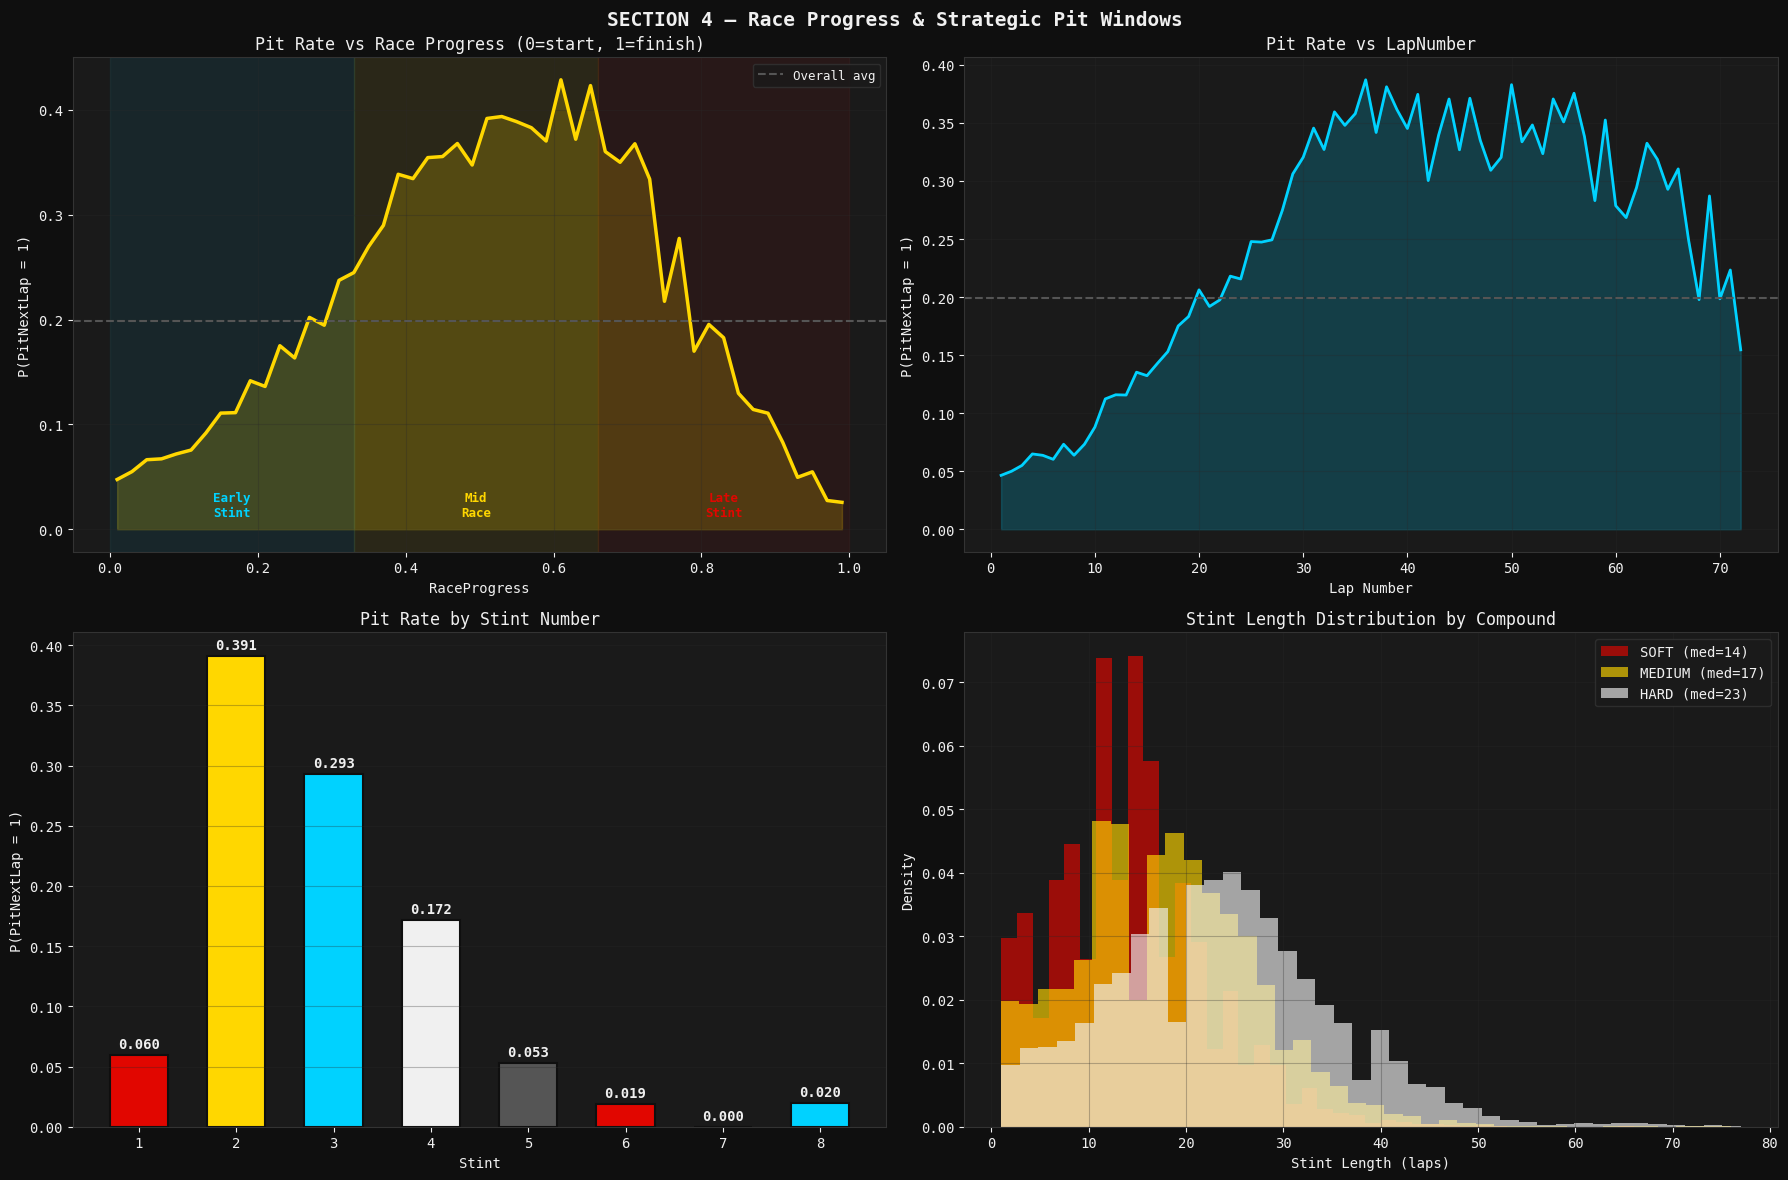

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('SECTION 4 — Race Progress & Strategic Pit Windows',
             fontsize=14, color=WHITE, fontweight='bold')

# 4a. Pit rate across RaceProgress
ax = axes[0, 0]
bins_prog = np.linspace(0, 1, 51)
train['RaceProg_bin'] = pd.cut(train['RaceProgress'], bins=bins_prog, labels=False)
pit_by_prog = train.groupby('RaceProg_bin')['PitNextLap'].agg(['mean', 'count']).reset_index()
pit_by_prog = pit_by_prog[pit_by_prog['count'] >= 100]
x_centers = (bins_prog[:-1] + bins_prog[1:]) / 2

ax.fill_between(x_centers[pit_by_prog['RaceProg_bin'].astype(int)],
                pit_by_prog['mean'], alpha=0.2, color=YELLOW)
ax.plot(x_centers[pit_by_prog['RaceProg_bin'].astype(int)],
        pit_by_prog['mean'], color=YELLOW, linewidth=2.5)
ax.axhline(train['PitNextLap'].mean(), color=GRAY, linestyle='--', linewidth=1.5,
           label='Overall avg')

# Annotate the three strategic windows
for x_start, x_end, label, color in [
    (0.0, 0.33, 'Early\nStint', CYAN),
    (0.33, 0.66, 'Mid\nRace', YELLOW),
    (0.66, 1.0, 'Late\nStint', RED)
]:
    ax.axvspan(x_start, x_end, alpha=0.07, color=color)
    ax.text((x_start + x_end) / 2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.01,
            label, ha='center', va='bottom', color=color, fontsize=9, fontweight='bold')

ax.set_title('Pit Rate vs Race Progress (0=start, 1=finish)', color=WHITE, fontsize=12)
ax.set_xlabel('RaceProgress')
ax.set_ylabel('P(PitNextLap = 1)')
ax.set_facecolor(PANEL)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

# 4b. Pit rate vs LapNumber
ax2 = axes[0, 1]
pit_by_lap = train.groupby('LapNumber')['PitNextLap'].agg(['mean', 'count']).reset_index()
pit_by_lap.columns = ['LapNumber', 'PitRate', 'Count']
pit_by_lap = pit_by_lap[pit_by_lap['Count'] >= 100]

ax2.fill_between(pit_by_lap['LapNumber'], pit_by_lap['PitRate'], alpha=0.2, color=CYAN)
ax2.plot(pit_by_lap['LapNumber'], pit_by_lap['PitRate'], color=CYAN, linewidth=2)
ax2.set_title('Pit Rate vs LapNumber', color=WHITE, fontsize=12)
ax2.set_xlabel('Lap Number')
ax2.set_ylabel('P(PitNextLap = 1)')
ax2.set_facecolor(PANEL)
ax2.grid(alpha=0.3)
ax2.axhline(train['PitNextLap'].mean(), color=GRAY, linestyle='--', linewidth=1.5)

# 4c. Stint distribution
ax3 = axes[1, 0]
stint_pit = train.groupby('Stint')['PitNextLap'].agg(['mean', 'count']).reset_index()
stint_pit.columns = ['Stint', 'PitRate', 'Count']
stint_pit = stint_pit[stint_pit['Count'] >= 50]

bars = ax3.bar(stint_pit['Stint'], stint_pit['PitRate'],
               color=[RED, YELLOW, CYAN, WHITE, GRAY][:len(stint_pit)],
               edgecolor=BG, linewidth=1.5, width=0.6)
for bar, val in zip(bars, stint_pit['PitRate']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
ax3.set_title('Pit Rate by Stint Number', color=WHITE, fontsize=12)
ax3.set_xlabel('Stint')
ax3.set_ylabel('P(PitNextLap = 1)')
ax3.set_facecolor(PANEL)
ax3.grid(axis='y', alpha=0.3)

# 4d. Stint length distribution
ax4 = axes[1, 1]
train_copy = train.copy()
stint_lengths = (train_copy.groupby(['Driver', 'Race', 'Year', 'Stint'])['TyreLife']
                 .max().reset_index())
stint_lengths.columns = ['Driver', 'Race', 'Year', 'Stint', 'StintLength']
stint_lengths['Compound'] = (train_copy.groupby(['Driver', 'Race', 'Year', 'Stint'])['Compound']
                              .first().values)

for comp in ['SOFT', 'MEDIUM', 'HARD']:
    if comp not in stint_lengths['Compound'].unique():
        continue
    data = stint_lengths[stint_lengths['Compound'] == comp]['StintLength']
    ax4.hist(data, bins=40, density=True, alpha=0.65,
             color=COMPOUND_COLORS[comp], label=f'{comp} (med={data.median():.0f})')

ax4.set_title('Stint Length Distribution by Compound', color=WHITE, fontsize=12)
ax4.set_xlabel('Stint Length (laps)')
ax4.set_ylabel('Density')
ax4.set_facecolor(PANEL)
ax4.grid(alpha=0.3)
ax4.legend(fontsize=10)

plt.tight_layout()
plt.savefig('04_race_progress.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Cleanup temp columns
train.drop(columns=['RaceProg_bin'], inplace=True)

**Pit rate by race stage:**

| Stage | Race Progress | Pit Rate |
|---|---|---|
| Formation | 0–20% | 8.6% |
| First window | 20–40% | 22.4% |
| **Primary window** | **40–60%** | **36.9% 🔴** |
| Second stops | 60–80% | 34.7% |
| End game | 80–100% | 11.2% |

The **40–80% race window** is where over 70% of all pit stops occur.  
Teams avoid late stops — giving up track position with no laps to recover it.

**Stint number is equally informative:**

| Stint | Pit Rate |
|---|---|
| 1 | 5.9% — fresh tyres, nobody stops |
| **2** | **39.1% 🔴 — highest** |
| 3 | 29.3% |
| 4 | 17.2% |
| 5+ | <6% — race is essentially over strategically |

> `IsFirstStint` is a strong suppressor — cars in Stint 1 almost never pit.  
> `Stint 2 or 3` combined with high TyreLife = near-certain pit signal.

## LAP TIME & DEGRADATION DEEP DIVE

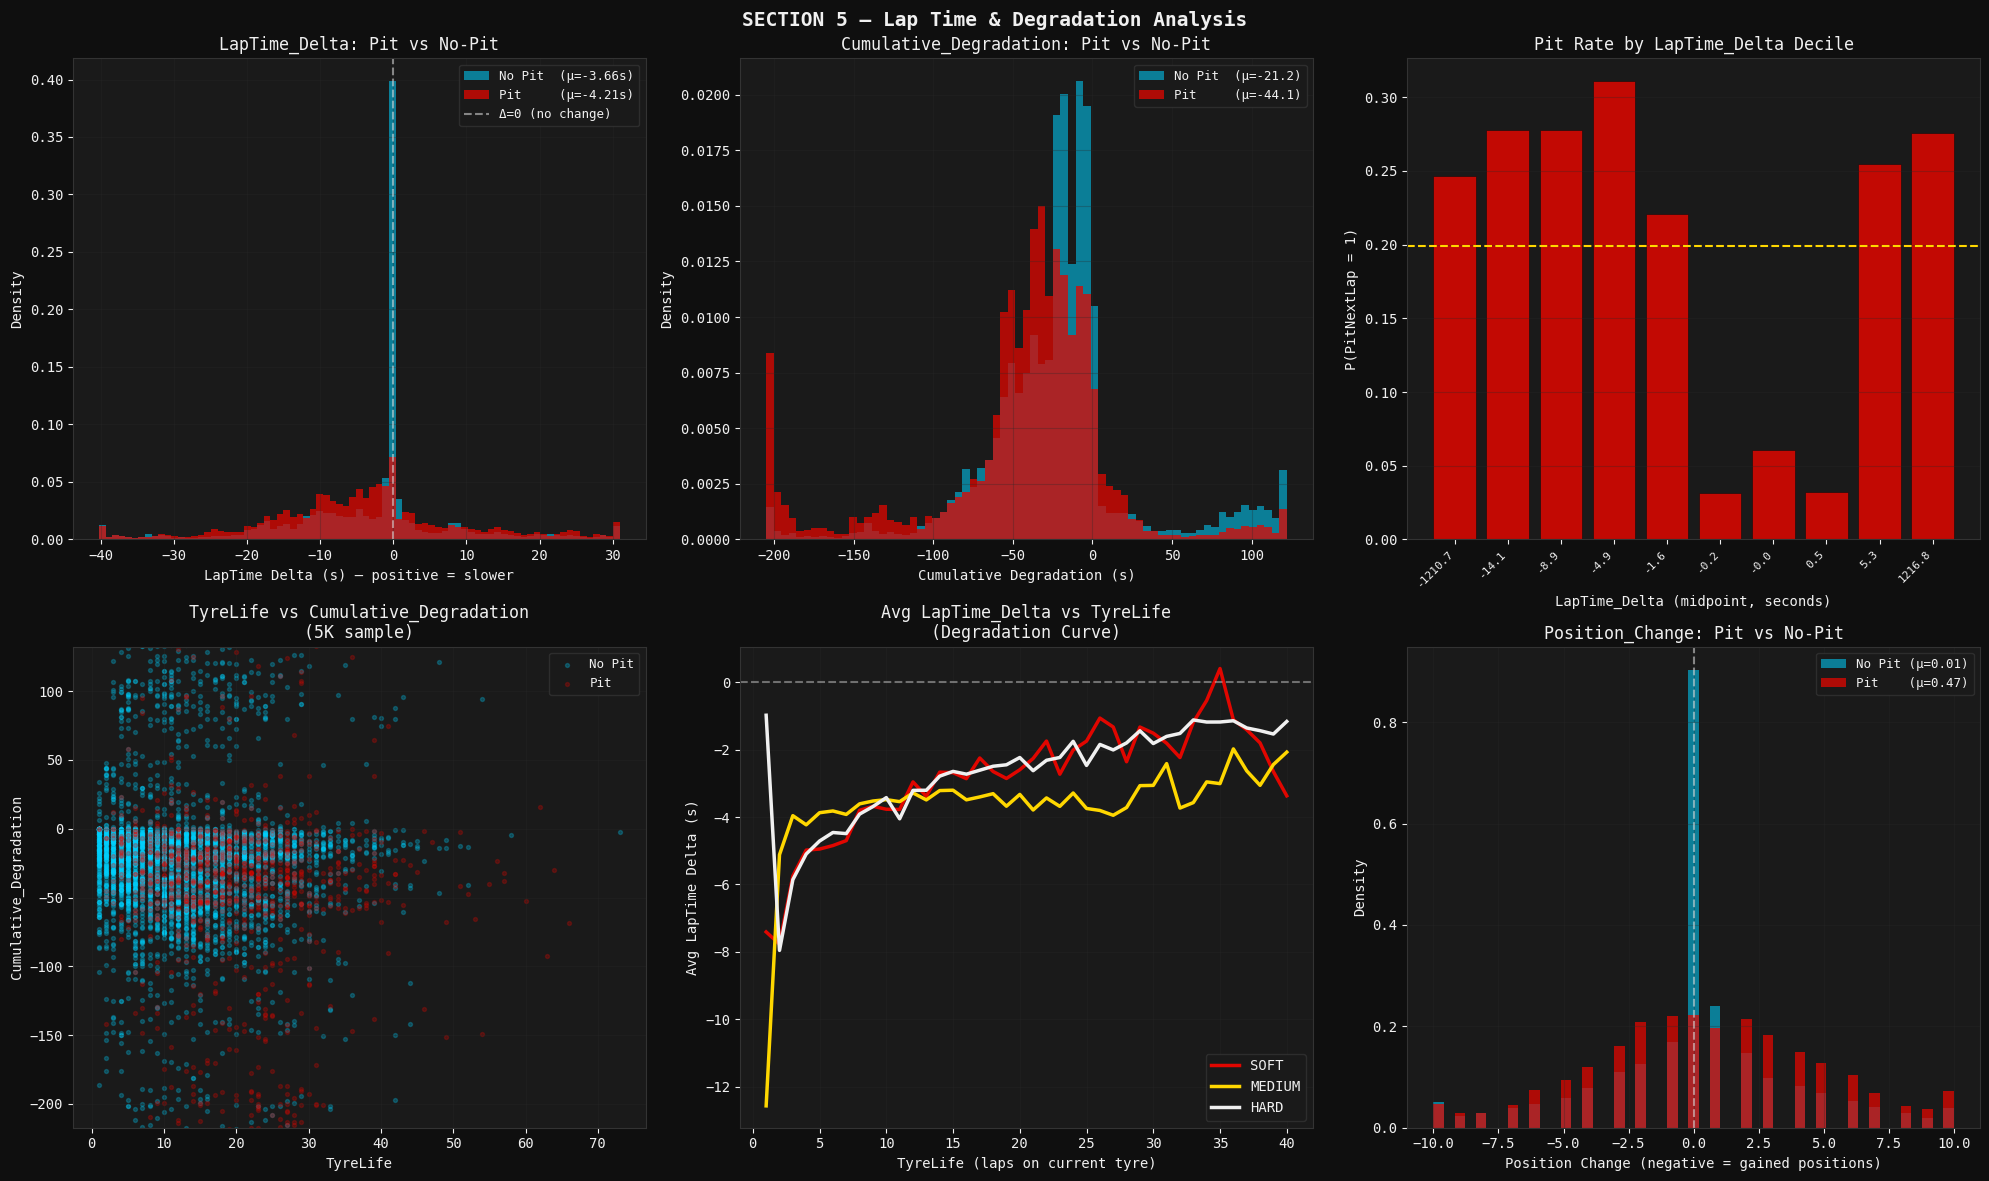

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig.suptitle('SECTION 5 — Lap Time & Degradation Analysis',
             fontsize=14, color=WHITE, fontweight='bold')

# 5a. LapTime_Delta distribution: pit vs no-pit
ax = axes[0, 0]
pit_delta    = train[train['PitNextLap'] == 1.0]['LapTime_Delta']
npit_delta   = train[train['PitNextLap'] == 0.0]['LapTime_Delta']
clip_lo, clip_hi = np.percentile(train['LapTime_Delta'], [1, 99])
bins_d = np.linspace(clip_lo, clip_hi, 80)
ax.hist(npit_delta.clip(clip_lo, clip_hi), bins=bins_d, density=True,
        alpha=0.55, color=CYAN, label=f'No Pit  (μ={npit_delta.mean():.2f}s)')
ax.hist(pit_delta.clip(clip_lo, clip_hi),  bins=bins_d, density=True,
        alpha=0.75, color=RED,  label=f'Pit     (μ={pit_delta.mean():.2f}s)')
ax.axvline(0, color=WHITE, linestyle='--', linewidth=1.5, alpha=0.5, label='Δ=0 (no change)')
ax.set_title('LapTime_Delta: Pit vs No-Pit', color=WHITE, fontsize=12)
ax.set_xlabel('LapTime Delta (s) — positive = slower')
ax.set_ylabel('Density')
ax.set_facecolor(PANEL)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

# 5b. Cumulative_Degradation at pit decision
ax2 = axes[0, 1]
pit_deg  = train[train['PitNextLap'] == 1.0]['Cumulative_Degradation']
npit_deg = train[train['PitNextLap'] == 0.0]['Cumulative_Degradation']
clip_lo2, clip_hi2 = np.percentile(train['Cumulative_Degradation'], [1, 99])
bins_deg = np.linspace(clip_lo2, clip_hi2, 70)
ax2.hist(npit_deg.clip(clip_lo2, clip_hi2), bins=bins_deg, density=True,
         alpha=0.55, color=CYAN, label=f'No Pit  (μ={npit_deg.mean():.1f})')
ax2.hist(pit_deg.clip(clip_lo2, clip_hi2),  bins=bins_deg, density=True,
         alpha=0.75, color=RED,  label=f'Pit     (μ={pit_deg.mean():.1f})')
ax2.set_title('Cumulative_Degradation: Pit vs No-Pit', color=WHITE, fontsize=12)
ax2.set_xlabel('Cumulative Degradation (s)')
ax2.set_ylabel('Density')
ax2.set_facecolor(PANEL)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)

# 5c. Pit rate by LapTime_Delta bucket
ax3 = axes[0, 2]
train_tmp = train.copy()
train_tmp['LapDelta_bin'] = pd.qcut(train_tmp['LapTime_Delta'], q=10, duplicates='drop')
pbr = train_tmp.groupby('LapDelta_bin')['PitNextLap'].mean()
x_labels = [f'{iv.mid:.1f}' for iv in pbr.index]
bars3 = ax3.bar(range(len(pbr)), pbr.values, color=RED, edgecolor=BG, linewidth=0.5, alpha=0.85)
ax3.set_xticks(range(len(pbr)))
ax3.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax3.set_title('Pit Rate by LapTime_Delta Decile', color=WHITE, fontsize=12)
ax3.set_xlabel('LapTime_Delta (midpoint, seconds)')
ax3.set_ylabel('P(PitNextLap = 1)')
ax3.set_facecolor(PANEL)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(train['PitNextLap'].mean(), color=YELLOW, linestyle='--', linewidth=1.5)

# 5d. Cumulative_Degradation vs TyreLife (scatter, sampled)
ax4 = axes[1, 0]
sample = train.sample(5000, random_state=42)
for val, color, label in [(0, CYAN, 'No Pit'), (1, RED, 'Pit')]:
    sub = sample[sample['PitNextLap'] == val]
    ax4.scatter(sub['TyreLife'], sub['Cumulative_Degradation'],
                c=color, alpha=0.25, s=8, label=label)
ax4.set_title('TyreLife vs Cumulative_Degradation\n(5K sample)', color=WHITE, fontsize=12)
ax4.set_xlabel('TyreLife')
ax4.set_ylabel('Cumulative_Degradation')
ax4.set_facecolor(PANEL)
ax4.grid(alpha=0.3)
ax4.legend(fontsize=9)
ax4.set_ylim(*np.percentile(train['Cumulative_Degradation'], [0.5, 99.5]))

# 5e. Lap time trend by compound (mean LapTime_Delta as TyreLife increases)
ax5 = axes[1, 1]
for comp in ['SOFT', 'MEDIUM', 'HARD']:
    if comp not in train['Compound'].unique():
        continue
    sub = train[train['Compound'] == comp]
    trend = sub.groupby('TyreLife')['LapTime_Delta'].mean()
    trend = trend[trend.index <= 40]
    ax5.plot(trend.index, trend.values, color=COMPOUND_COLORS[comp],
             linewidth=2.5, label=comp)
ax5.axhline(0, color=WHITE, linestyle='--', linewidth=1.5, alpha=0.4)
ax5.set_title('Avg LapTime_Delta vs TyreLife\n(Degradation Curve)', color=WHITE, fontsize=12)
ax5.set_xlabel('TyreLife (laps on current tyre)')
ax5.set_ylabel('Avg LapTime Delta (s)')
ax5.set_facecolor(PANEL)
ax5.grid(alpha=0.3)
ax5.legend(fontsize=10)

# 5f. Position_Change distribution
ax6 = axes[1, 2]
pit_pos    = train[train['PitNextLap'] == 1.0]['Position_Change']
npit_pos   = train[train['PitNextLap'] == 0.0]['Position_Change']
bins_pos = np.linspace(-10, 10, 50)
ax6.hist(npit_pos.clip(-10, 10), bins=bins_pos, density=True,
         alpha=0.55, color=CYAN, label=f'No Pit (μ={npit_pos.mean():.2f})')
ax6.hist(pit_pos.clip(-10, 10),  bins=bins_pos, density=True,
         alpha=0.75, color=RED,  label=f'Pit    (μ={pit_pos.mean():.2f})')
ax6.axvline(0, color=WHITE, linestyle='--', linewidth=1.5, alpha=0.5)
ax6.set_title('Position_Change: Pit vs No-Pit', color=WHITE, fontsize=12)
ax6.set_xlabel('Position Change (negative = gained positions)')
ax6.set_ylabel('Density')
ax6.set_facecolor(PANEL)
ax6.grid(alpha=0.3)
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_laptime_degradation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**LapTime_Delta** has near-zero linear correlation (r = -0.005) with pit stops — but the decile chart tells a different story. Pit rate follows a **U-shape**: spikes at very negative deltas (safety cars, outliers) and very positive deltas (dying tyres), drops to just 3–6% for stable laps in the middle. This signal is completely invisible to linear models. Use `LapTime_Delta²` or decile bins.

**Cumulative_Degradation** ⚠️ behaves correctly in 2022–2024 rows (starts at 0, grows negative as car gets faster). In 2025 synthetic rows it jumps randomly within the same stint — corrupted. Despite this, pit laps still show significantly more negative values (median -33.2 vs -19.9), so it retains signal as a *laps-completed proxy*. Use it, but don't engineer physics-based features from it.

**Position_Change** — cars predictably lose positions on pit laps (mean +0.47 vs +0.01 for no-pit). Both medians are zero, so convert to a binary flag rather than using as continuous.

## DATASET SHIFT: SYNTHETIC vs ORIGINAL

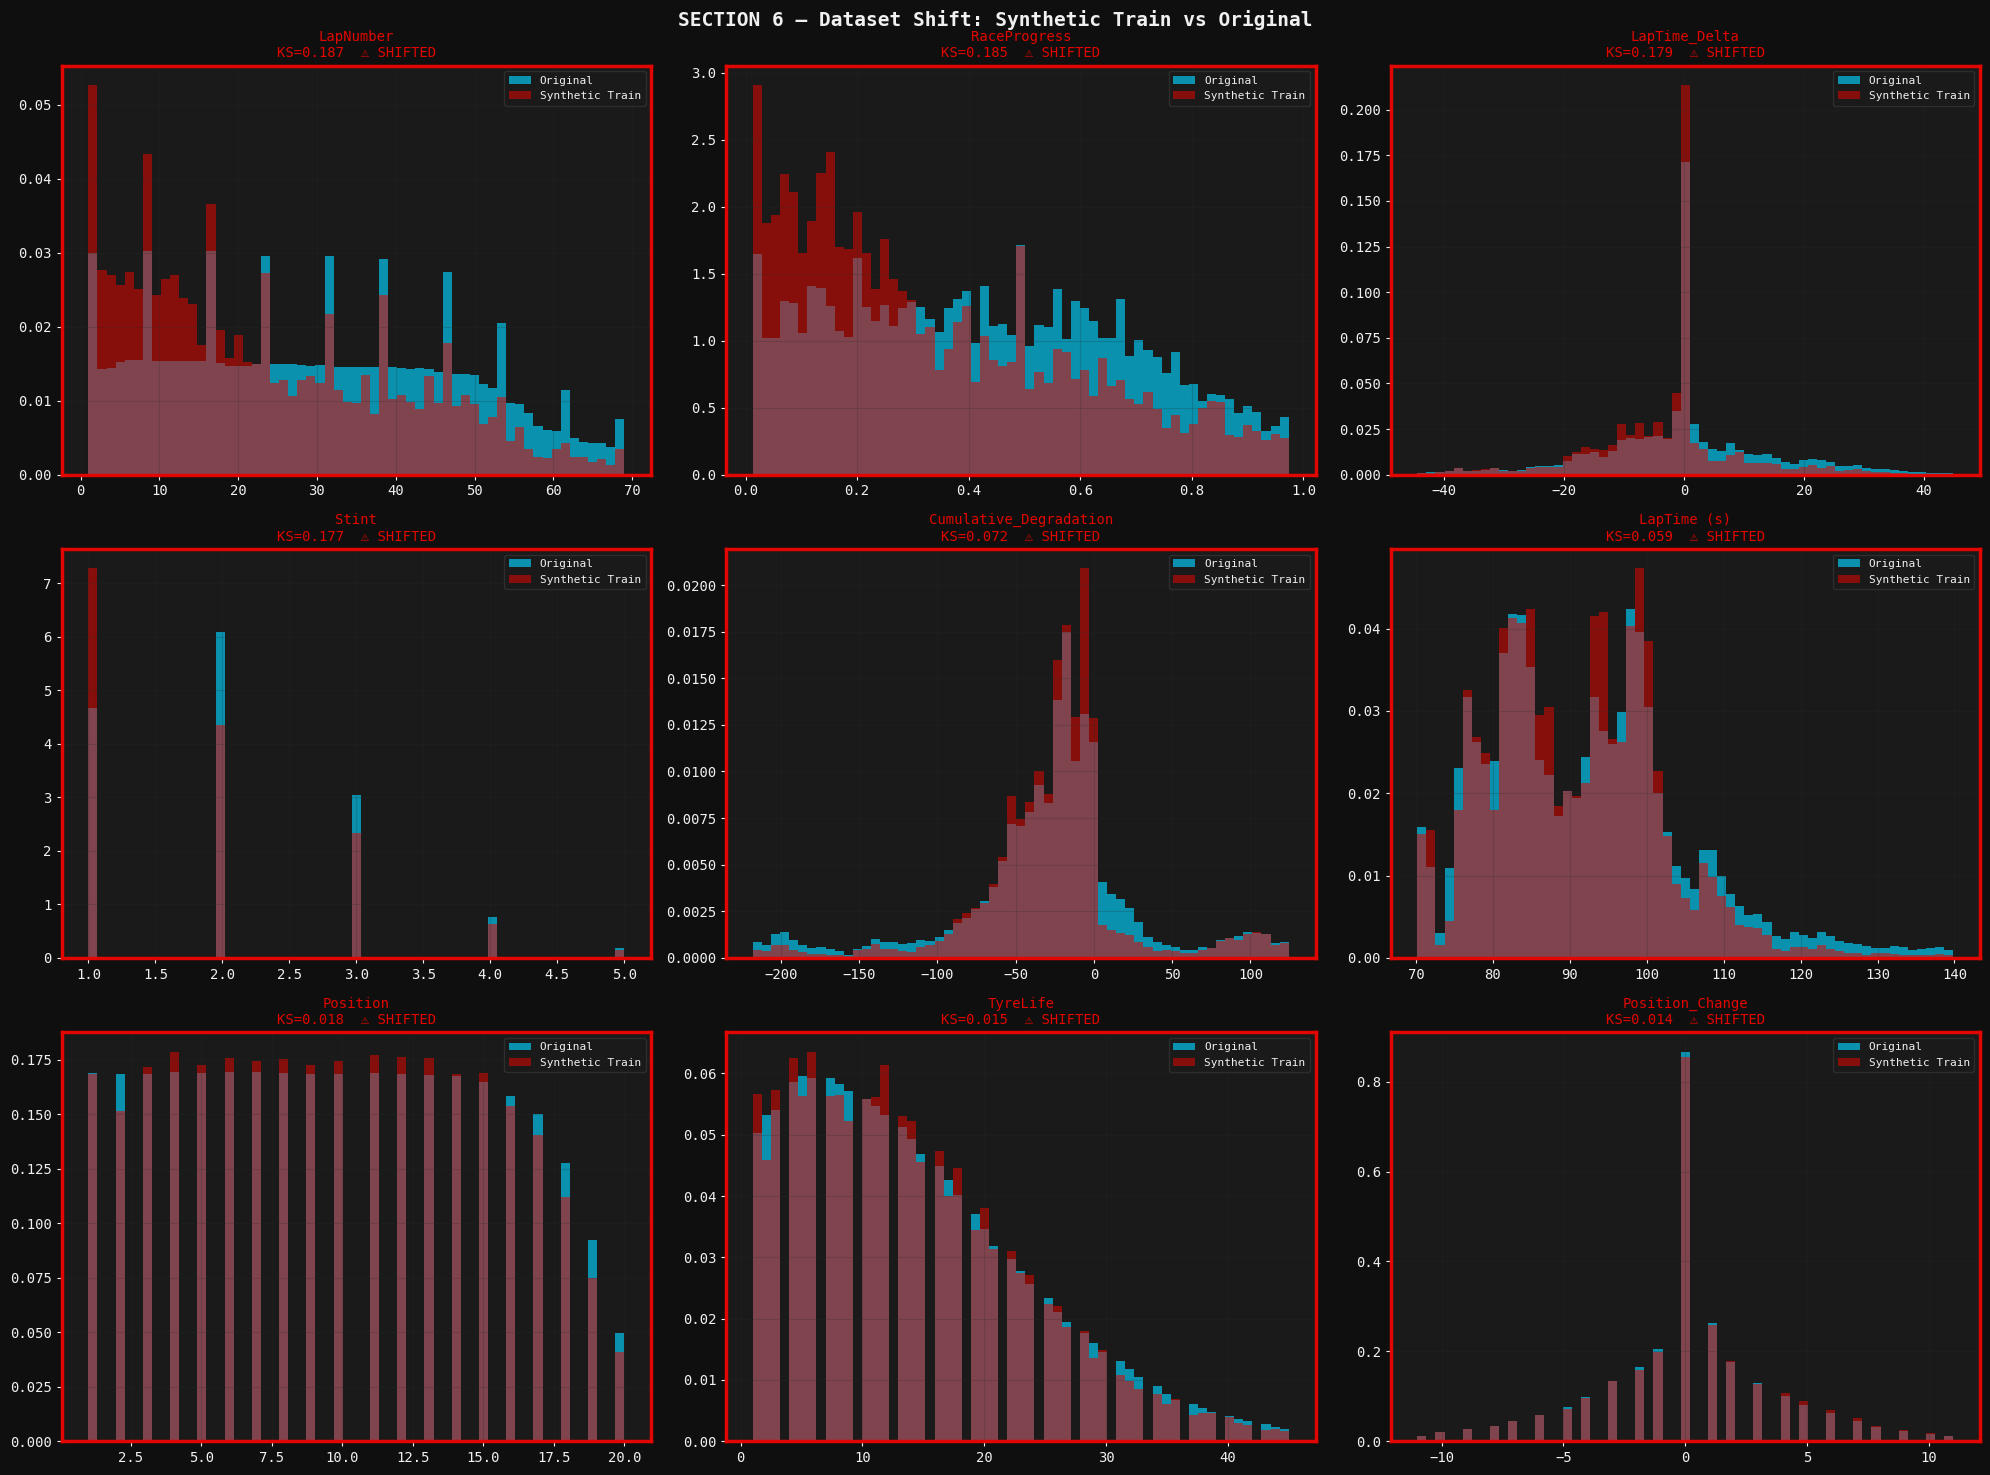

In [9]:
num_feats = ['TyreLife', 'LapTime (s)', 'LapTime_Delta',
             'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
             'Position', 'LapNumber', 'Stint']

ks_results = []
for col in num_feats:
    if col not in orig.columns:
        continue
    stat, p = ks_2samp(train[col].values, orig[col].values)
    ks_results.append({'Feature': col, 'KS_stat': stat, 'p_value': p,
                       'Shifted': p < 0.05})
ks_df = pd.DataFrame(ks_results).sort_values('KS_stat', ascending=False)

fig, axes = plt.subplots(3, 3, figsize=(20, 15), facecolor=BG)
fig.suptitle('SECTION 6 — Dataset Shift: Synthetic Train vs Original',
             fontsize=14, color=WHITE, fontweight='bold')
axes = axes.flatten()

for i, row in enumerate(ks_df.itertuples()):
    ax = axes[i]
    col = row.Feature
    shifted = row.Shifted

    bins = np.linspace(
        min(train[col].quantile(0.01), orig[col].quantile(0.01)),
        max(train[col].quantile(0.99), orig[col].quantile(0.99)),
        60
    )
    ax.hist(orig[col], bins=bins, density=True, alpha=0.65,
            color=CYAN, label='Original')
    ax.hist(train[col], bins=bins, density=True, alpha=0.55,
            color=RED,  label='Synthetic Train')

    border_color = RED if shifted else '#39b54a'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5)

    ax.set_title(f'{col}\nKS={row.KS_stat:.3f}  {"⚠ SHIFTED" if shifted else "✓ stable"}',
                 color=border_color if shifted else '#39b54a', fontsize=10)
    ax.set_facecolor(PANEL)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('06_dataset_shift.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

Every single feature is statistically shifted (all p < 0.05).  
But severity varies enormously — and that changes how we use the original data.

| Feature | KS Stat | Severity |
|---|---|---|
| LapNumber | 0.187 | 🔴 High |
| RaceProgress | 0.185 | 🔴 High |
| LapTime_Delta | 0.179 | 🔴 High |
| Stint | 0.177 | 🔴 High |
| Cumulative_Degradation | 0.072 | 🟡 Medium |
| LapTime (s) | 0.059 | 🟡 Medium |
| Position | 0.018 | 🟢 Low |
| Position_Change | 0.014 | 🟢 Low |
| TyreLife | 0.016 | 🟢 Low |

**Compound distribution also shifted:**  
Original has more HARD (44%) and SOFT (13%) — synthetic has more MEDIUM (48%).  
Soft tyre behaviour is **underrepresented** in the synthetic training data.

**Recommended strategy for using original data:**
- ✅ **Safe to add directly:** TyreLife, Position, Position_Change (KS < 0.02)
- ⚠️ **Add with `is_original=1` flag:** RaceProgress, LapNumber, Stint, LapTime_Delta
- The model will learn when original-domain patterns apply vs synthetic ones
- Consider downweighting original rows (`sample_weight = 0.7`) on high-shift features

> The target rate gap (19.9% synthetic vs 25.5% original) means original data  
> adds **proportionally more positive examples** — directly helping with class imbalance.

## CORRELATION & FEATURE RELATIONSHIPS

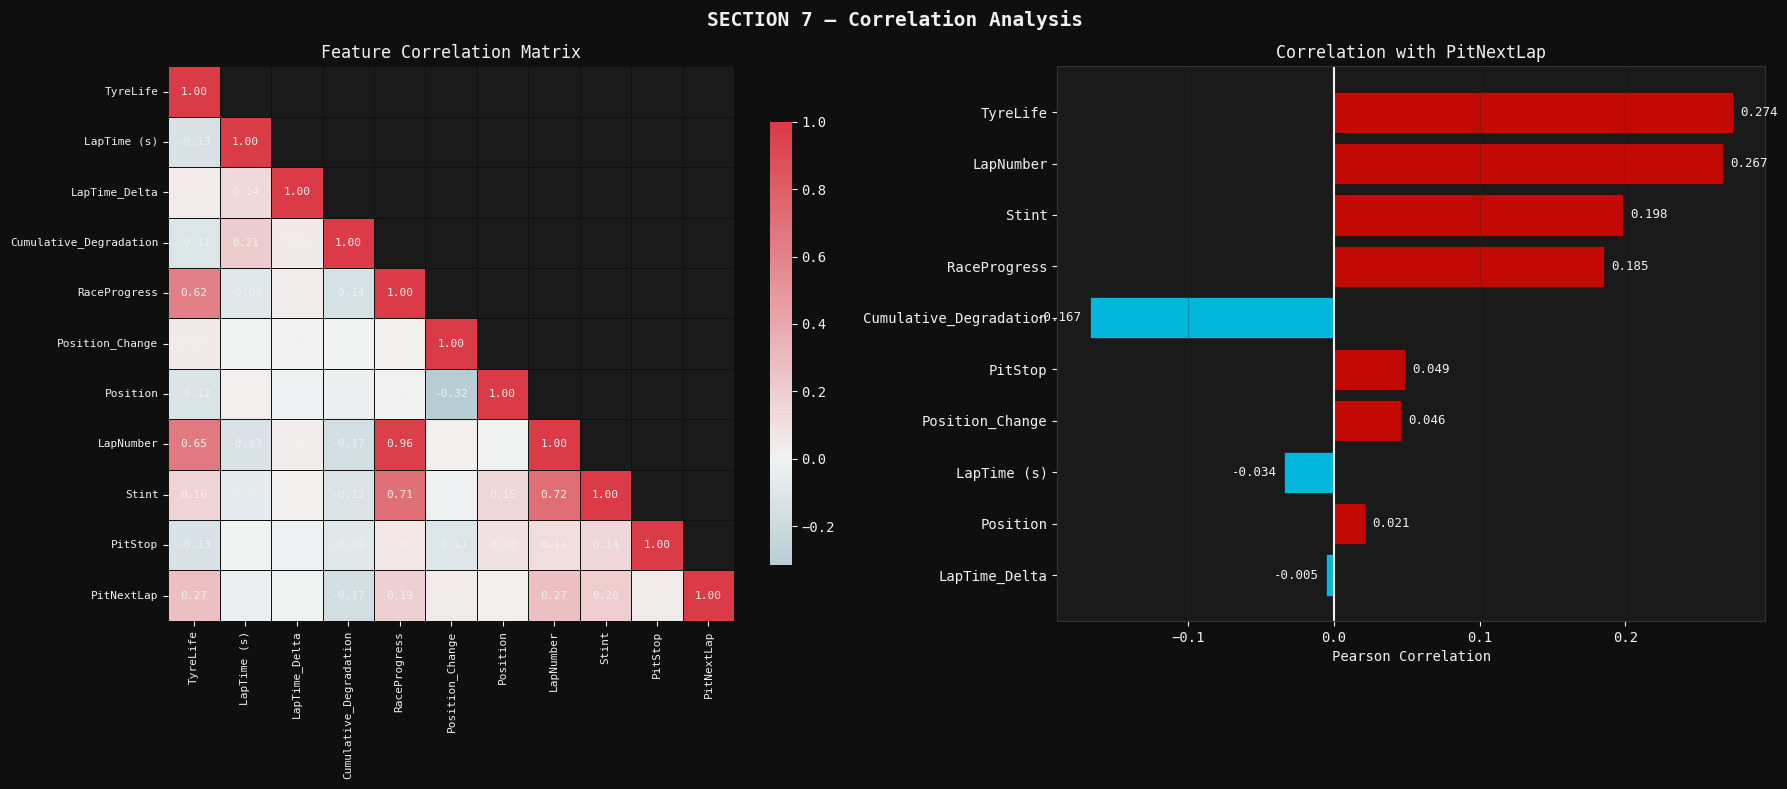

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG)
fig.suptitle('SECTION 7 — Correlation Analysis',
             fontsize=14, color=WHITE, fontweight='bold')

ax = axes[0]
corr_cols = ['TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
             'RaceProgress', 'Position_Change', 'Position', 'LapNumber', 'Stint',
             'PitStop', 'PitNextLap']
corr = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, ax=ax, linewidths=0.5, linecolor='#111111',
            annot_kws={'size': 8, 'color': WHITE},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', color=WHITE, fontsize=12)
ax.set_facecolor(PANEL)
ax.tick_params(colors=WHITE, labelsize=8)

ax2 = axes[1]
target_corr = (corr['PitNextLap']
               .drop('PitNextLap')
               .sort_values(key=abs, ascending=True))
colors = [RED if v > 0 else CYAN for v in target_corr.values]
bars = ax2.barh(target_corr.index, target_corr.values,
                color=colors, edgecolor=BG, linewidth=0.5, alpha=0.85)
ax2.axvline(0, color=WHITE, linewidth=1.5)
for bar, val in zip(bars, target_corr.values):
    ax2.text(val + 0.005 * np.sign(val), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val > 0 else 'right',
             color=WHITE, fontsize=9)
ax2.set_title('Correlation with PitNextLap', color=WHITE, fontsize=12)
ax2.set_xlabel('Pearson Correlation')
ax2.set_facecolor(PANEL)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('07_correlations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

| Feature | Correlation with PitNextLap |
|---|---|
| TyreLife | **+0.274** 🔴 |
| LapNumber | +0.267 |
| Stint | +0.198 |
| RaceProgress | +0.185 |
| Cumulative_Degradation | -0.167 |
| PitStop | +0.049 |
| Position_Change | +0.046 |
| LapTime (s) | -0.034 |
| Position | +0.021 |
| LapTime_Delta | -0.005 ⚠️ |

**Three things worth flagging:**

**`PitStop` (+0.049)** — a car that pitted *this* lap correlates with pitting *next* lap. This sounds like leakage but it isn't — it reflects back-to-back stint transitions in the data structure. Safe to use but worth monitoring.

**`LapTime_Delta` (-0.005)** — essentially zero linear correlation. Don't let this fool you into dropping it. The median gap between pit and no-pit laps is enormous (-4.30s vs -0.14s). The signal is real, it's just nonlinear — it needs to be interacted with TyreLife to show up.

**`Cumulative_Degradation` (-0.167)** — negative correlation means *more* degradation = *more* likely to pit, which makes sense. But as we saw in Section 5, this feature is corrupted in 2025 synthetic rows. Use with caution.

---

## Summary — What Actually Triggers a Pit Stop?

After a full analysis of 439K laps across multiple F1 seasons, the answer is clear:

1. **Tyre age is everything.** TyreLife is the strongest predictor (r = 0.27), and its effect is compound-specific — a Soft at lap 13 is as likely to pit as a Hard at lap 61.

2. **Race timing matters almost as much.** The 40–80% race window accounts for the majority of stops. Cars in Stint 1 almost never pit (5.9% rate).

3. **Lap time signal is real but nonlinear.** LapTime_Delta has near-zero linear correlation — but the median gap between pit and no-pit laps is huge (-4.30s vs -0.14s). Use it as an interaction, not a standalone feature.

4. **The synthetic data is not the original.** All 9 features are shifted. The competition host lowered the pit rate from 25.5% to 19.9%. Use original data, but flag it.

5. **The removed column (`Normalized_TyreLife`) can be reconstructed.** TyreLife divided by compound-specific median stint length approximates it well. This is likely the single highest-impact feature engineering step in this competition.

---

*If this was useful, please consider upvoting 🙌*

[RealMLP](https://www.kaggle.com/code/simarbirsinghsandhu/realmlp-encoding-fe) (PB 0.95253) | [CatBoost](https://www.kaggle.com/code/simarbirsinghsandhu/catboost-gpu-fe-encoding) (PB: 0.95) | [XGB GPU](https://www.kaggle.com/code/simarbirsinghsandhu/xgboost-gpu-fe-encoding)

